#  Khám phá và Tiền xử lý dữ liệu (ShanghaiTech Dataset)


**Nội dung thực hiện:**
1. Khai báo môi trường và cấu hình đường dẫn.
2. Làm sạch dữ liệu .
3. Khám phá thống kê (EDA).
4. Tạo Density Map .
5. Trực quan hóa mẫu dữ liệu (Visualization).
6. Tăng cường dữ liệu .



##  1. Thiết lập môi trường và đường dẫn



In [45]:
import os
import glob
import h5py
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.io as sio
import PIL.Image as Image
from matplotlib import pyplot as plt
from matplotlib import cm as CM
from scipy.ndimage import gaussian_filter
from scipy.spatial import KDTree
from tqdm import tqdm
import random


PROJECT_ROOT  = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_ROOT     = os.path.join(PROJECT_ROOT, "data")
SHANGHAI_ROOT = os.path.join(DATA_ROOT, "ShanghaiTech")


PART_A_TRAIN  = os.path.join(SHANGHAI_ROOT, "part_A", "train_data")
PART_A_TEST   = os.path.join(SHANGHAI_ROOT, "part_A", "test_data")
PART_B_TRAIN  = os.path.join(SHANGHAI_ROOT, "part_B", "train_data")
PART_B_TEST   = os.path.join(SHANGHAI_ROOT, "part_B", "test_data")


## 2. Làm sạch dữ liệu

In [46]:
def clean_dataset(part="A"):
    paths = [PART_A_TRAIN, PART_A_TEST] if part == "A" else [PART_B_TRAIN, PART_B_TEST]
    print(f"\n--- Kiểm tra Part {part} ---")
    
    for p in paths:
        imgs = glob.glob(os.path.join(p, "images/*.jpg"))
        errors = 0
        
        for img_p in imgs:
            mat_p = img_p.replace(".jpg", ".mat").replace("images", "ground-truth").replace("IMG_", "GT_IMG_")
            try:
                if not os.path.exists(mat_p): raise ValueError()
                with Image.open(img_p) as img: img.verify()
            except:
                errors += 1
                
        status = "Sạch" if errors == 0 else f"={errors} Lỗi"
        print(f" {os.path.basename(p):<10}: {len(imgs):>3} images | {status}")

clean_dataset("A")
clean_dataset("B")



--- Kiểm tra Part A ---
 train_data: 300 images | Sạch
 test_data : 182 images | Sạch

--- Kiểm tra Part B ---
 train_data: 400 images | Sạch
 test_data : 316 images | Sạch


## 3. Khám phá thống kê (EDA)


--- Thống kê Part A Train ---
             count        width       height
count   300.000000   300.000000   300.000000
mean    541.376667   872.193333   598.270000
std     505.162984   213.851375   165.865775
min      33.000000   299.000000   182.000000
25%     238.750000   689.500000   460.250000
50%     378.000000  1024.000000   652.500000
75%     652.500000  1024.000000   688.000000
max    3138.000000  1024.000000  1024.000000


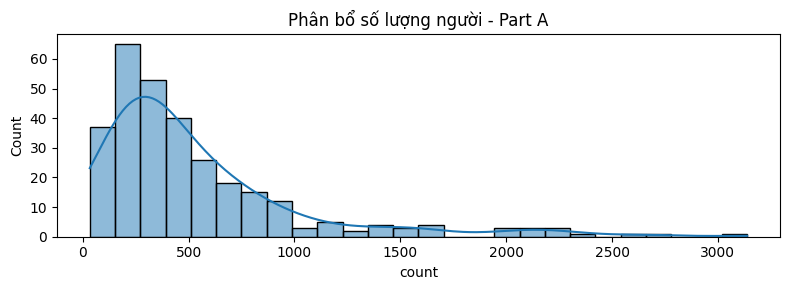


--- Thống kê Part B Train ---
           count   width  height
count  400.00000   400.0   400.0
mean   122.87750  1024.0   768.0
std     93.88647     0.0     0.0
min     12.00000  1024.0   768.0
25%     50.75000  1024.0   768.0
50%     99.00000  1024.0   768.0
75%    161.00000  1024.0   768.0
max    576.00000  1024.0   768.0


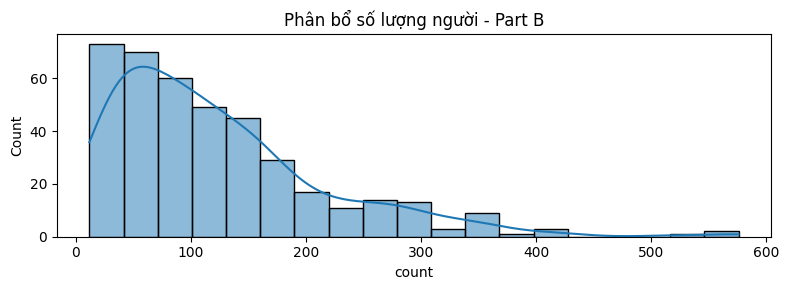

In [47]:
def get_stats(train_path):
    img_paths = glob.glob(os.path.join(train_path, "images", "*.jpg"))
    counts, dims = [], []
    for img_p in img_paths:
        mat_p = (img_p
                 .replace(".jpg", ".mat")
                 .replace("images", "ground-truth")
                 .replace("IMG_", "GT_IMG_"))
        if os.path.exists(mat_p):
            mat = sio.loadmat(mat_p)
            counts.append(len(mat["image_info"][0, 0][0, 0][0]))
            with Image.open(img_p) as img:
                dims.append(img.size)
    return pd.DataFrame({
        "count":  counts,
        "width":  [d[0] for d in dims],
        "height": [d[1] for d in dims],
    })


for part, path in [("A", PART_A_TRAIN), ("B", PART_B_TRAIN)]:
    try:
        df = get_stats(path)
        print(f"\n--- Thống kê Part {part} Train ---")
        print(df.describe())
        plt.figure(figsize=(8, 3))
        sns.histplot(df["count"], kde=True)
        plt.title(f"Phân bổ số lượng người - Part {part}")
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Lỗi khi xử lý Part {part}: {e}")


## 4. Tạo Density Map

In [48]:
def generate_density_map(img_shape, points, adaptive_kernel=True, k=3, beta=0.3, fixed_sigma=15):
    height, width = img_shape
    density = np.zeros((height, width), dtype=np.float32)
    if len(points) == 0: return density
    
    if adaptive_kernel and len(points) > k:

        tree = KDTree(points, leafsize=2048)
        distances, _ = tree.query(points, k=k+1)
        sigmas = np.mean(distances[:, 1:], axis=1) * beta
        sigmas = np.clip(sigmas, 1, 50)
    else:
        sigmas = np.full(len(points), fixed_sigma, dtype=np.float32)
        
    for i, (x, y) in enumerate(points):
        ix, iy = int(round(x)), int(round(y))
        if iy >= height or ix >= width or iy < 0 or ix < 0: continue
            
        sigma = sigmas[i]
        radius = int(sigma * 3)
        
        y_min = max(0, iy - radius)
        y_max = min(height, iy + radius + 1)
        x_min = max(0, ix - radius)
        x_max = min(width, ix + radius + 1)
        
        local_h, local_w = y_max - y_min, x_max - x_min
        local_pt2d = np.zeros((local_h, local_w), dtype=np.float32)
        local_pt2d[iy - y_min, ix - x_min] = 1.0
        
       
        blurred = gaussian_filter(local_pt2d, sigma, mode='constant')
        

        total_density = blurred.sum()
        if total_density > 0:
            blurred = blurred / total_density
        
        density[y_min:y_max, x_min:x_max] += blurred
        
    return density

def process_dataset(path, part='A', force_regenerate=True):
    img_paths = sorted(glob.glob(os.path.join(path, "images", "*.jpg")))
    print(f"\n--- Generating Density Maps for Part {part} ({len(img_paths)} images) ---")
    
    # Khởi tạo các biến để tính tổng sai số
    total_error = 0
    
    for p in tqdm(img_paths):
        mat_p = p.replace(".jpg", ".mat").replace("images", "ground-truth").replace("IMG_", "GT_IMG_")
        h5_p  = p.replace(".jpg", ".h5").replace("images", "ground-truth")
        
        # Bỏ qua nếu option force_regenerate là Ghi đè (True) 
        if os.path.exists(h5_p) and not force_regenerate: 
            continue
            
        img = Image.open(p)
        mat = sio.loadmat(mat_p)
        gt = mat["image_info"][0, 0][0, 0][0]
        
  
        dm = generate_density_map((img.size[1], img.size[0]), gt, adaptive_kernel=(part == 'A'))
        
      
        gt_count = len(gt)              
        dm_sum = np.sum(dm)             
        error = abs(gt_count - dm_sum)
        total_error += error
      
        if error > 0.5:
            print(f"ẢNH BÁO tại file {os.path.basename(p)}: Ground Truth = {gt_count}, Trong khi tính ra np.sum = {dm_sum:.4f} (Sai lệch: {error:.4f})")
        # ---------------------------------------------
        
        with h5py.File(h5_p, 'w') as f:
            f.create_dataset('density', data=dm)

    mean_error = total_error / len(img_paths)
    print(f"Hoàn tất tập Part {part}. MAE Sai số Tổng/Điểm Ground-truth: {mean_error:.5f}")

process_dataset(PART_A_TRAIN, part='A', force_regenerate=True)
process_dataset(PART_A_TEST, part='A', force_regenerate=True)
process_dataset(PART_B_TRAIN, part='B', force_regenerate=True)
process_dataset(PART_B_TEST, part='B', force_regenerate=True)



--- Generating Density Maps for Part A (300 images) ---


 20%|██        | 61/300 [00:05<00:21, 11.35it/s]

ẢNH BÁO tại file IMG_151.jpg: Ground Truth = 987, Trong khi tính ra np.sum = 985.0000 (Sai lệch: 2.0000)


 25%|██▌       | 75/300 [00:06<00:16, 13.84it/s]

ẢNH BÁO tại file IMG_165.jpg: Ground Truth = 468, Trong khi tính ra np.sum = 467.0000 (Sai lệch: 1.0000)


...

ẢNH BÁO tại file IMG_23.jpg: Ground Truth = 240, Trong khi tính ra np.sum = 239.0000 (Sai lệch: 1.0000)
ẢNH BÁO tại file IMG_232.jpg: Ground Truth = 133, Trong khi tính ra np.sum = 132.0000 (Sai lệch: 1.0000)


 97%|█████████▋| 307/316 [00:23<00:00, 14.30it/s]

ẢNH BÁO tại file IMG_88.jpg: Ground Truth = 163, Trong khi tính ra np.sum = 162.0000 (Sai lệch: 1.0000)


100%|██████████| 316/316 [00:23<00:00, 13.24it/s]

Hoàn tất tập Part B. MAE Sai số Tổng/Điểm Ground-truth: 0.03481


## 5. Trực quan hóa mẫu dữ liệu (Visualization)


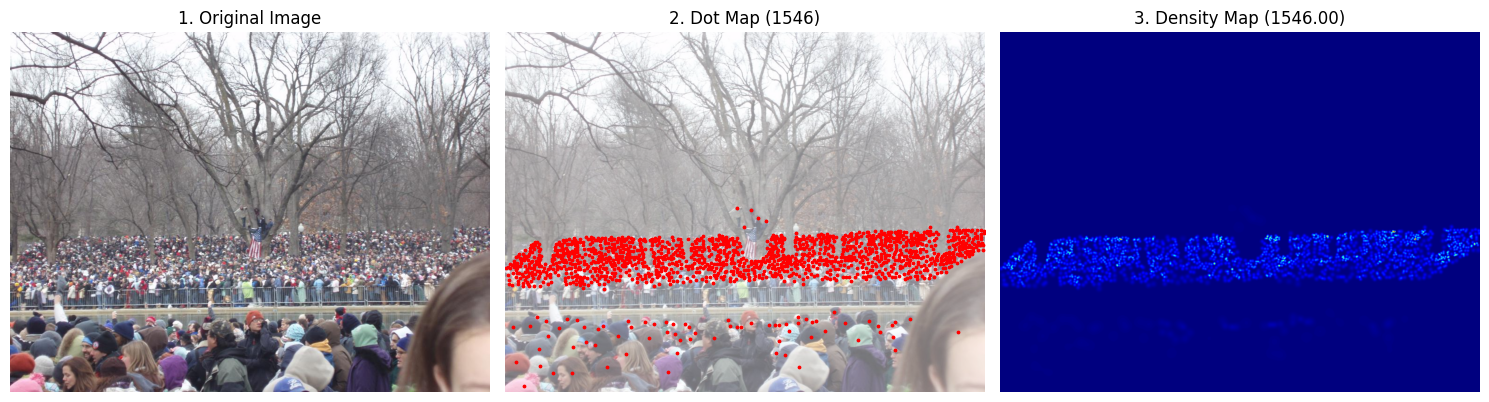

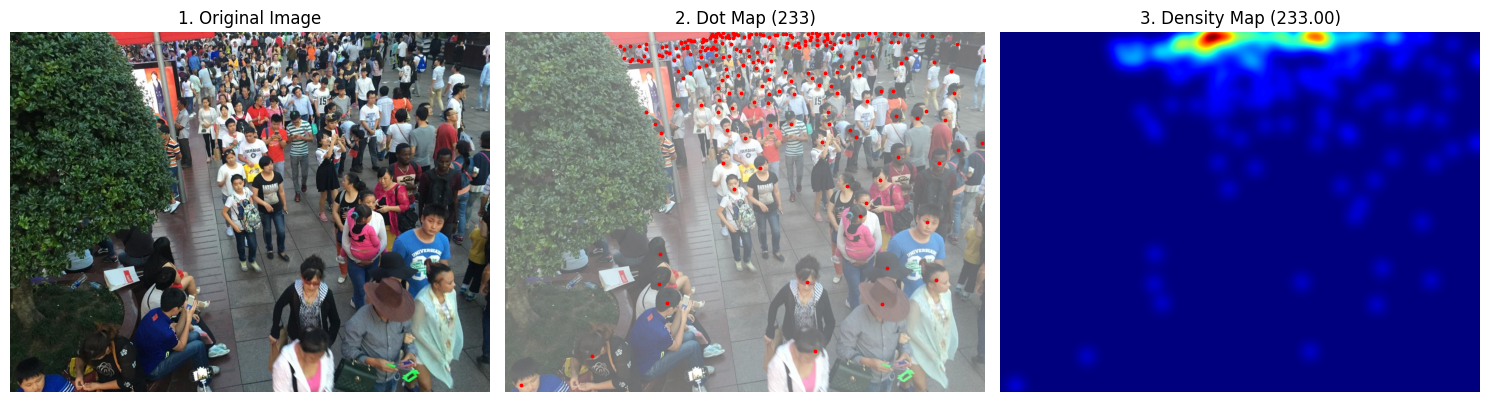

In [49]:
def check_h5_sample(img_no, part="A", subset="train_data"):
    base_path = os.path.join(SHANGHAI_ROOT, f"part_{part}", subset)
    img_p = os.path.join(base_path, "images", f"IMG_{img_no}.jpg")
    mat_p = os.path.join(base_path, "ground-truth", f"GT_IMG_{img_no}.mat")
    h5_p  = os.path.join(base_path, "ground-truth", f"IMG_{img_no}.h5")

    if not all(os.path.exists(f) for f in [img_p, mat_p, h5_p]):
        print(f"Thiếu dữ liệu cho IMG_{img_no}")
        return

    # Load dữ liệu
    img = Image.open(img_p)
    gt  = sio.loadmat(mat_p)["image_info"][0, 0][0, 0][0]
    with h5py.File(h5_p, "r") as hf: dm = np.asarray(hf["density"])

    # Hiển thị
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    titles = ["1. Original Image", f"2. Dot Map ({len(gt)})", f"3. Density Map ({dm.sum():.2f})"]
    
    axes[0].imshow(img)
    # Chồng dots lên ảnh gốc để dễ quan sát hơn
    axes[1].imshow(img, alpha=0.6)
    axes[1].scatter(gt[:, 0], gt[:, 1], s=3, c="red")
    axes[2].imshow(dm, cmap=CM.jet)

    for i, ax in enumerate(axes):
        ax.set_title(titles[i])
        ax.axis("off")
        
    plt.tight_layout()
    plt.show()

# Kiểm tra thử mẫu
check_h5_sample(1, part="A")
check_h5_sample(1, part="B")


## 6. Tăng cường dữ liệu


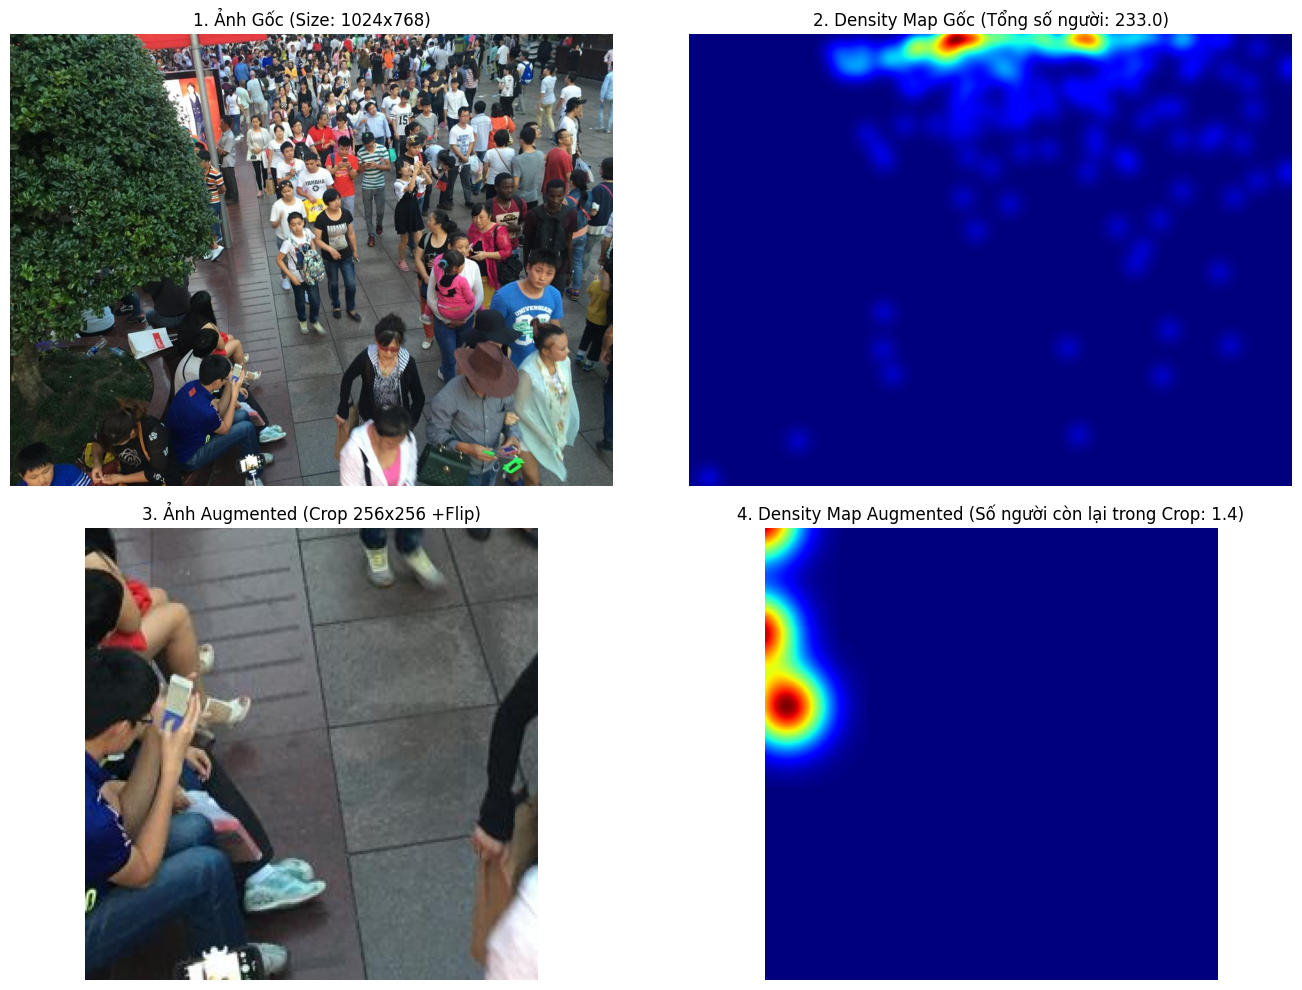

In [ ]:
def augment_sample_advanced(img_no, part="A", crop_size=(256, 256)):
    train_path = os.path.join(SHANGHAI_ROOT, f"part_{part}", "train_data")
    img_p = os.path.join(train_path, "images", f"IMG_{img_no}.jpg")
    h5_p  = os.path.join(train_path, "ground-truth", f"IMG_{img_no}.h5")

    if not os.path.exists(img_p) or not os.path.exists(h5_p):
        print(f"Không tìm thấy file cho IMG_{img_no} Part {part}")
        return


    img = Image.open(img_p).convert('RGB')
    with h5py.File(h5_p, "r") as hf:
        dm = np.asarray(hf["density"])

    W, H = img.size
    cw, ch = crop_size
    
    x1 = random.randint(0, max(0, W - cw) if W > cw else 0)
    y1 = random.randint(0, max(0, H - ch) if H > ch else 0)
    
    img_aug = img.crop((x1, y1, x1 + cw, y1 + ch))
    dm_aug = dm[y1:y1 + ch, x1:x1 + cw]
    
    # Bước 2: Random Horizontal Flip (Áp dụng cho CẢ img và dm với xác suất 50%)
    if random.random() > 0.5:
        img_aug = img_aug.transpose(Image.FLIP_LEFT_RIGHT)
        dm_aug = np.fliplr(dm_aug) 
        

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
 
    axes[0, 0].imshow(img)
    axes[0, 0].set_title(f"1. Ảnh Gốc (Size: {W}x{H})")
    
    axes[0, 1].imshow(dm, cmap='jet')
    axes[0, 1].set_title(f"2. Density Map Gốc (Tổng số người: {np.sum(dm):.1f})")
    
    axes[1, 0].imshow(img_aug)
    axes[1, 0].set_title(f"3. Ảnh Augmented (Crop {cw}x{ch} +Flip)")
    
    axes[1, 1].imshow(dm_aug, cmap='jet')
    axes[1, 1].set_title(f"4. Density Map Augmented (Số người còn lại trong Crop: {np.sum(dm_aug):.1f})")
    
    for ax in axes.flatten():
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()


augment_sample_advanced(1, part="B")


In [51]:
import cv2

def augment_data(img_path, h5_path, save_dir, num_crops=4, crop_size=256):
    """
    Thực hiện Random Crop và Horizontal Flip cho cả ảnh và bản đồ mật độ.
    """
    # Đọc ảnh và bản đồ mật độ
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    with h5py.File(h5_path, 'r') as hf:
        density = np.asarray(hf.get('density'))
        
    h, w = img.shape[:2]
    base_name = os.path.basename(img_path).replace('.jpg', '')
    
    # Tạo thư mục lưu nếu chưa có
    aug_img_dir = os.path.join(save_dir, 'images')
    aug_h5_dir = os.path.join(save_dir, 'ground-truth')
    os.makedirs(aug_img_dir, exist_ok=True)
    os.makedirs(aug_h5_dir, exist_ok=True)

    for i in range(num_crops):
        # 1. Random Crop
        if h > crop_size and w > crop_size:
            dx = random.randint(0, w - crop_size)
            dy = random.randint(0, h - crop_size)
        else:
            dx, dy = 0, 0
            # Nếu ảnh nhỏ hơn crop_size thì resize hoặc skip (ở đây skip để giữ chất lượng)
            continue
            
        img_crop = img[dy:dy+crop_size, dx:dx+crop_size]
        den_crop = density[dy:dy+crop_size, dx:dx+crop_size]
        
        # 2. Horizontal Flip (xác suất 50%)
        if random.random() > 0.5:
            img_crop = cv2.flip(img_crop, 1)
            den_crop = cv2.flip(den_crop, 1)
            
        # Lưu ảnh augmented
        save_name = f"{base_name}_aug_{i}.jpg"
        Image.fromarray(img_crop).save(os.path.join(aug_img_dir, save_name))
        
        # Lưu mật độ augmented
        with h5py.File(os.path.join(aug_h5_dir, save_name.replace('.jpg', '.h5')), 'w') as hf:
            hf.create_dataset('density', data=den_crop)

# Ví dụ chạy thử augmentation cho Part A Train
# Lưu ý: Việc này sẽ tạo ra 300 * 4 = 1200 ảnh huấn luyện mới
AUG_PART_A_TRAIN = os.path.join(SHANGHAI_ROOT, "part_A", "augmented_train")

print("Đang thực hiện Augmentation cho Part A...")
train_imgs = glob.glob(os.path.join(PART_A_TRAIN, "images", "*.jpg"))

for img_p in tqdm(train_imgs):
    h5_p = img_p.replace("images", "ground-truth").replace(".jpg", ".h5")
    augment_data(img_p, h5_p, AUG_PART_A_TRAIN, num_crops=4, crop_size=256)

print(f"Hoàn tất! Dữ liệu tăng cường được lưu tại: {AUG_PART_A_TRAIN}")


Đang thực hiện Augmentation cho Part A...


100%|██████████| 300/300 [00:10<00:00, 29.16it/s]

Hoàn tất! Dữ liệu tăng cường được lưu tại: c:\Users\Kien\Documents\GitHub\TGMT\data\ShanghaiTech\part_A\augmented_train
